## “How did COVID-19 impact regional house price dispersion across UK counties?”
### Notebook 1 - Data Cleaning and Preparation

Source
https://www.gov.uk/government/statistical-data-sets/uk-house-price-index-data-downloads-december-

Information on dataset
https://www.gov.uk/government/publications/about-the-uk-house-price-index/about-the-uk-house-price-index#data-tables


1. Import house prices dataset
2. Initial data inspection
3. Sort data into regions  
   3.1 Bring in region dataset  
   3.2 Clean region dataset and handle missing counties / regions  
   3.3 Form new dataframe from both datasets, adress formatting (dates)  
4. Clean full dataset  
   4.1 Investigate missing values

5. Comparing regions
   Pivot tables into regions, plot region average price against time.

   

In [3]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates

### 1. Import house prices dataset

In [5]:
filepath = "../data/UK-HPI-full-file-2025-12.csv"

#### Create a dataframe from csv

In [7]:
data = pd.read_csv(filepath)

### 2. Initial data inspection

#### Examine data

In [10]:
print(f"Data shape:{data.shape}")
data.head()

Data shape:(149085, 54)


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [11]:
data.describe()

,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,DetachedPrice,DetachedIndex,Detached1m%Change,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
count,1.490850e+05,149085.000000,5244.000000,148632.000000,144225.000000,5244.000000,144618.000000,1.422840e+05,142284.000000,141889.000000,...,1.416640e+05,141664.000000,141268.000000,136936.000000,138483.000000,1.418680e+05,141868.000000,141472.000000,137140.000000,141858.000000
mean,1.831012e+05,59.835763,62.132113,0.526866,6.100826,168752.656941,1252.600105,3.420380e+05,59.933395,0.461848,...,2.196692e+05,61.681981,0.497958,6.245756,135.956161,1.847985e+05,60.045649,0.472946,6.054274,1138.200045
std,1.311841e+05,26.619737,25.039764,1.934405,8.622357,94882.354669,7707.191260,3.432452e+05,25.206280,1.697813,...,1.342548e+05,26.401143,1.751680,7.974581,843.840990,1.310111e+05,25.507217,1.730925,8.408653,6965.933714
min,2.553000e+03,0.800000,13.900000,-30.300000,-35.800000,39008.000000,2.000000,4.011700e+04,9.400000,-19.600000,...,2.244300e+04,8.000000,-29.800000,-28.900000,1.000000,2.271600e+04,9.000000,-30.600000,-30.300000,2.000000
25%,1.005410e+05,38.200000,46.600000,-0.500000,1.100000,116135.000000,140.000000,1.785228e+05,41.200000,-0.500000,...,1.279912e+05,42.400000,-0.500000,1.700000,10.000000,1.021160e+05,40.900000,-0.500000,1.000000,126.000000
50%,1.547560e+05,61.000000,62.600000,0.500000,5.100000,153018.500000,215.000000,2.603840e+05,60.000000,0.400000,...,1.982200e+05,61.600000,0.500000,5.400000,21.000000,1.549365e+05,60.800000,0.500000,5.100000,193.000000
75%,2.301380e+05,80.300000,80.400000,1.400000,10.100000,209241.750000,376.000000,3.961765e+05,79.800000,1.400000,...,2.780390e+05,82.800000,1.500000,10.100000,46.000000,2.312262e+05,79.600000,1.400000,10.200000,343.000000
max,1.656986e+06,153.100000,110.000000,35.300000,98.400000,574627.000000,183609.000000,5.820174e+06,147.000000,34.800000,...,1.414204e+06,149.600000,34.900000,96.200000,21097.000000,1.665089e+06,152.700000,35.600000,98.600000,166098.000000


#### Review missing variables


In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 54 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Date                    149085 non-null  str    
 1   RegionName              149085 non-null  str    
 2   AreaCode                149085 non-null  str    
 3   AveragePrice            149085 non-null  int64  
 4   Index                   149085 non-null  float64
 5   IndexSA                 5244 non-null    float64
 6   1m%Change               148632 non-null  float64
 7   12m%Change              144225 non-null  float64
 8   AveragePriceSA          5244 non-null    float64
 9   SalesVolume             144618 non-null  float64
 10  DetachedPrice           142284 non-null  float64
 11  DetachedIndex           142284 non-null  float64
 12  Detached1m%Change       141889 non-null  float64
 13  Detached12m%Change      137568 non-null  float64
 14  SemiDetachedPrice       142284 

We can see there are 53 columns, and a lot have missing values. We likely only the first 4-5 columns though

### 3. ASSIGN COUNTIES TO REGIONS
In order to investigate the question whether differences in regional house prices have reduced since Covid, we will simplify by splitting the country into regions, as a crude first measure, using government defined regions.

### Investigating area codes

In [17]:
unique_area_codes = data['AreaCode'].unique()
print(set([i[0] for i in unique_area_codes]))

{'W', 'S', 'E', 'N', 'K'}


In [18]:
print(set([i[0:3] for i in unique_area_codes]))

{'N09', 'E06', 'K03', 'K04', 'E13', 'W92', 'E12', 'E11', 'E08', 'K02', 'E09', 'W06', 'E10', 'E92', 'S92', 'N92', 'E07', 'S12'}


In [19]:
total_area_codes = len(unique_area_codes)
idx = 0
while idx <= total_area_codes:
    print(unique_area_codes[idx:idx+10])
    idx = idx+10
    

<StringArray>
['S12000034', 'E07000223', 'E07000032', 'S12000041', 'N09000001', 'N09000011',
 'S12000035', 'N09000002', 'E07000224', 'E07000170']
Length: 10, dtype: str
<StringArray>
['E07000105', 'E07000200', 'E09000002', 'E09000003', 'E08000038', 'E07000066',
 'E07000084', 'E07000171', 'E06000022', 'E06000055']
Length: 10, dtype: str
<StringArray>
['N09000003', 'E09000004', 'E08000025', 'E07000129', 'E06000008', 'E06000009',
 'W06000019', 'E07000033', 'E08000001', 'E07000136']
Length: 10, dtype: str
<StringArray>
['E06000058', 'E06000036', 'E08000032', 'E07000067', 'E07000143', 'E09000005',
 'E07000068', 'W06000013', 'E06000043', 'E07000144']
Length: 10, dtype: str
<StringArray>
['E09000006', 'E07000234', 'E07000095', 'E07000172', 'E06000060', 'E07000117',
 'E08000002', 'W06000018', 'E08000033', 'E07000008']
Length: 10, dtype: str
<StringArray>
['E10000003', 'E09000007', 'E07000192', 'E07000106', 'W06000015', 'W06000010',
 'E07000069', 'N09000004', 'E06000056', 'W06000008']
Length: 1

Area codes appear to be in format N-01-000-001, where the first letter is a country code, next two digits a regional code then last 3 a county / unitary / district authority or london borough.

There are country codes; E,K,N,S,W. These could be England, ?, Northern Ireland, Scotland and Wales.
The secondary codes for E are : 06 to 13 and 92.
The secondary codes for K are 02-04.
The secondary codes for N are 09,92.
The secondary codes for S are 12.
The secondary codes for W are 06,92.

In [21]:
### create a region column
data['Country'] = data['AreaCode'].str[0]

#### Create a new dataframe from key columns

For now we will use only the columns; date, region name, averagePrice and country. There are no missing values in these columns

In [23]:
data_s = data[['Date','RegionName','AreaCode','AveragePrice','Country']]
data_s.head()

,Date,RegionName,AreaCode,AveragePrice,Country
0,01/01/2004,Aberdeenshire,S12000034,84638,S
1,01/02/2004,Aberdeenshire,S12000034,84623,S
2,01/03/2004,Aberdeenshire,S12000034,86536,S
3,01/04/2004,Aberdeenshire,S12000034,87373,S
4,01/05/2004,Aberdeenshire,S12000034,89493,S


In [24]:
data_s.info()

<class 'pandas.DataFrame'>
RangeIndex: 149085 entries, 0 to 149084
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Date          149085 non-null  str  
 1   RegionName    149085 non-null  str  
 2   AreaCode      149085 non-null  str  
 3   AveragePrice  149085 non-null  int64
 4   Country       149085 non-null  str  
dtypes: int64(1), str(4)
memory usage: 5.7 MB


### Investigating the area codes further

Now we have country codes, what region names are in each country?

In [26]:
group = data_s.groupby('Country')['RegionName'].unique()
print(group.values)

[<StringArray>
 [                    'Adur',             'Amber Valley',
                      'Arun',                 'Ashfield',
                   'Ashford',                  'Babergh',
      'Barking and Dagenham',                   'Barnet',
                  'Barnsley',                 'Basildon',
  ...
                 'Wokingham',            'Wolverhampton',
                 'Worcester',           'Worcestershire',
                  'Worthing',                 'Wychavon',
                      'Wyre',              'Wyre Forest',
                      'York', 'Yorkshire and The Humber']
 Length: 334, dtype: str
 <StringArray>
 ['England and Wales', 'Great Britain', 'United Kingdom']
 Length: 3, dtype: str
 <StringArray>
 [            'Antrim and Newtownabbey',                 'Ards and North Down',
  'Armagh City Banbridge and Craigavon',                             'Belfast',
             'Causeway Coast and Glens',             'Derry City and Strabane',
                  'Ferm

__We can see the region letter (i.e. the area code first letter), refers to England (E), Northern Ireland (N), 
Scotland (S) and Wales (W), not in fact North, South, East, West.__

### 3.1 Introduce gov defined regions and assign counties to regions

__It may be more useful to split counties into regions.
The below csv includes a list of counties and their associated regions, from another government source.__

In [28]:
region_counties = pd.read_csv("../data/uk-counties-to-regions.csv")
region_counties.head()

,County,Region
0,Guernsey,Crown Dependencies
1,IOM,Crown Dependencies
2,Jersey,Crown Dependencies
3,North East Derbyshire,East Midlands
4,Amber Valley,East Midlands


In [29]:
print(region_counties.duplicated().any())

True


__Here we've introduced some data that may need cleaning__

#### 3.2 Clean county-region assignments

In [31]:
### find the duplicates, then use these to subset original dataframe to find all the counties duplicated convert to list
duplicated_counties = region_counties[region_counties.duplicated()]['County'].to_list()
# subset the region counties dataframe to extract just the duplicated counties
duplicates_subset = region_counties[region_counties['County'].isin(duplicated_counties)]

# find the where more tha one region is assigned to a county
mask = duplicates_subset.groupby('County')['Region'].nunique() > 1

# create an index of these
problem_counties= mask[mask].index


In [32]:
print(region_counties[region_counties['County'].isin(problem_counties)])

              County                    Region
31      Lincolnshire             East Midlands
32      Lincolnshire             East Midlands
153  North Yorkshire        North East England
516     Lincolnshire  Yorkshire and the Humber
519  North Yorkshire  Yorkshire and the Humber
520  North Yorkshire  Yorkshire and the Humber


__So we can see there are some counties where there are two regions assigned for one county: Lincolnshire and North Yorkshire.__
__Let's clean it up__.

In [34]:
region_counties.loc[region_counties['County'] == 'Lincolnshire','Region']='East Midlands'
region_counties.loc[region_counties['County'] == 'North Yorkshire','Region']='Yorkshire and the Humber'

__Let's just check that...__

In [36]:
print(region_counties.groupby('County')['Region'].nunique().max()==1)

True


In [37]:
### show list of regions from counties list

regions = region_counties['Region'].unique()
print(regions)

<StringArray>
[      'Crown Dependencies',            'East Midlands',
          'East of England',                   'London',
       'North East England', 'Yorkshire and the Humber',
       'North West England',         'Northern Ireland',
                 'Scotland',       'South East England',
       'South West England',                    'Wales',
            'West Midlands']
Length: 13, dtype: str


In [38]:
counties = region_counties['County'].tolist()
print("Counties",len(counties))

region_names = data_s['RegionName'].unique().tolist()
print("Unique region names",len(region_names))


Counties 531
Unique region names 405



__There are 405 region names in our original dataset. But the list of counties and unitary from a different source gives us 531 counties.__


#### List region names not in counties list

In [41]:
region_names_not_in_counties = set(region_names)-set(counties)
print(len(region_names_not_in_counties))
print(region_names_not_in_counties)

52
{'City of Dundee', 'Yorkshire and The Humber', 'City of Aberdeen', 'Newcastle upon Tyne', 'Armagh City Banbridge and Craigavon', 'East of England', 'Fermanagh and Omagh', 'West Northamptonshire', 'Mid and East Antrim', 'England and Wales', 'Folkestone and Hythe', 'East Midlands', 'City of Plymouth', 'Inner London', 'Bournemouth Christchurch and Poole', 'East Suffolk', 'North Northamptonshire', 'Mid Ulster', 'Ards and North Down', 'Northern Ireland', 'Antrim and Newtownabbey', 'City of Kingston upon Hull', 'Scottish Borders', 'City of Derby', 'West Suffolk', 'England', 'City of Nottingham', 'Lisburn and Castlereagh', 'Great Britain', 'North West', 'West Midlands Region', 'Na h-Eileanan Siar', 'South East', 'Westmorland and Furness', 'North East', 'Rhondda Cynon Taf', 'Vale of Glamorgan', 'Newry Mourne and Down', 'Wales', "King's Lynn and West Norfolk ", 'Outer London', 'Derry City and Strabane', 'London', 'North East Derbyshire', 'Scotland', 'South West', 'City of Glasgow', 'Causeway

Not as simple as we would of liked. There are some names in region_names that are not in our list of counties.
There is a map available at: https://geoportal.statistics.gov.uk/documents/1aa806eb35ee4334a87f5970c82e3ac0/explore

There is a list available at: https://assets.publishing.service.gov.uk/media/603901d7e90e070566dafa58/Regions_and_local_authorities_at_01-04-21.pdf

I manually use the above data to create the dictionary below.

In [43]:
region_names_to_regions = {'City of Plymouth':'South West England', 'City of Aberdeen':'Scotland', 'Fermanagh and Omagh':'Northern Ireland', 
                           'Causeway Coast and Glens':'Northern Ireland', 'Scotland':'Scotland', 'Na h-Eileanan Siar':'Scotland', 
                           'Scottish Borders':'Scotland', 'East Suffolk':'East of England', 'Inner London':'London', 
                         'West Midlands Region':'West Midlands', 'West Suffolk':'East of England', 'Mid and East Antrim':'Northern Ireland', 
                         'Derry City and Strabane':'Northern Ireland', 'United Kingdom':'none', 'Westmorland and Furness':'North West England', 
                         'Antrim and Newtownabbey':'Northern Ireland', 'Newcastle upon Tyne':'North East England', 
                           'Bournemouth Christchurch and Poole':'South West England', 
                         'North East Derbyshire':'East Midlands', 'Newry Mourne and Down':'Northern Ireland', 
                           'Mid Ulster':'Northern Ireland', 'Great Britain':'none', 
                         'Rhondda Cynon Taf':'Wales', 'City of Derby':'East Midlands', 
                           'Yorkshire and The Humber':'Yorkshire and the Humber', 'East of England':'East of England', 
                         'North East':'North East England', 'City of Glasgow':'Scotland', 'Folkestone and Hythe':'South East England', 
                           'West Northamptonshire':'East Midlands', 'England and Wales':'none', 
                         'City of Kingston upon Hull':'Yorkshire and the Humber', 'East Midlands':'East Midlands', 'Outer London':'London', 
                         'Northern Ireland':'Northern Ireland', 'Ards and North Down':'Northern Ireland', 
                         'City of Peterborough':'East of England', 'Vale of Glamorgan':'Wales', 'South West':'South West England', 
                         'Armagh City Banbridge and Craigavon':'Northern Ireland', 
                         'Lisburn and Castlereagh':'Northern Ireland', 'North West':'North West England', 
                         'City of Dundee':'Scotland', 'City of Nottingham':'East Midlands', 
                         "King's Lynn and West Norfolk ":'East of England' , 'Wales':'Wales', 
                         'Richmond upon Thames':'London', 'England':'none', 'South East':'South East England', 
                         'North Northamptonshire':'East Midlands', 'London':'London', 'Cumberland':'North West England'}




### Convert our dictionary of missing counties to a dataframe

In [45]:
missing_counties = pd.DataFrame.from_dict(region_names_to_regions,orient='index')
missing_counties = missing_counties.reset_index(drop=False)
missing_counties.columns = ['County','Region']
missing_counties.head()

,County,Region
0,City of Plymouth,South West England
1,City of Aberdeen,Scotland
2,Fermanagh and Omagh,Northern Ireland
3,Causeway Coast and Glens,Northern Ireland
4,Scotland,Scotland


In [46]:
# concatenate into one lookup dataframe

print(region_counties.shape)
print(missing_counties.shape)

all_counties = pd.concat([region_counties,missing_counties])

print(all_counties.shape)
print(all_counties.tail())

(531, 2)
(52, 2)
(583, 2)
                    County              Region
47                 England                none
48              South East  South East England
49  North Northamptonshire       East Midlands
50                  London              London
51              Cumberland  North West England


__Now we have a mapping from counties to region in a separate dataframe. But the counties are (confusingly) called RegionName in our original dataset so we need to prepare for merge.__

### 3.3 Merge the dataframes, data_s and all_counties to get a region column

In [49]:
# rename column in original dataset to county
data_s.rename(columns= {"RegionName":"County"},inplace=True)
data_s.head()

,Date,County,AreaCode,AveragePrice,Country
0,01/01/2004,Aberdeenshire,S12000034,84638,S
1,01/02/2004,Aberdeenshire,S12000034,84623,S
2,01/03/2004,Aberdeenshire,S12000034,86536,S
3,01/04/2004,Aberdeenshire,S12000034,87373,S
4,01/05/2004,Aberdeenshire,S12000034,89493,S


In [50]:
data_s = data_s.merge(all_counties, on='County',how='left')
data_s.head()


,Date,County,AreaCode,AveragePrice,Country,Region
0,01/01/2004,Aberdeenshire,S12000034,84638,S,Scotland
1,01/02/2004,Aberdeenshire,S12000034,84623,S,Scotland
2,01/03/2004,Aberdeenshire,S12000034,86536,S,Scotland
3,01/04/2004,Aberdeenshire,S12000034,87373,S,Scotland
4,01/05/2004,Aberdeenshire,S12000034,89493,S,Scotland


__Nice now we have a region column where all our counties are categorised into regions__


### Clean dates

__Ok so now we have cleanly assigned all counties to a region, we may want to check the state of the dates. What we need is the same set of dates for all counties, so we can aggregate across counties for each date.__

In [52]:
print(data_s.groupby('County')['Date'].unique())

County
Aberdeenshire               [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Adur                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Amber Valley                [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Angus                       [01/01/2004, 01/02/2004, 01/03/2004, 01/04/200...
Antrim and Newtownabbey     [01/01/2005, 01/02/2005, 01/03/2005, 01/04/200...
                                                  ...                        
Wychavon                    [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Wyre Forest                 [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
York                        [01/01/1995, 01/02/1995, 01/03/1995, 01/04/199...
Yorkshire and The Humber    [01/04/1968, 01/05/1968, 01/06/1968, 01/07/196...
Name: Date, Length: 405, dtype: object


__Oh dear this looks messy.__
__All counties obviously don't have the same dates, but it looks like we could be quite a long way off.__
__Let's create a new dataframe based on a new index with dates and counties as indexes__

In [54]:
print(data_s.duplicated().sum())
print(data_s.shape)

9936
(159021, 6)


In [55]:
dup_mask = data_s.duplicated(keep=False)
data_s[dup_mask]

,Date,County,AreaCode,AveragePrice,Country,Region
15564,01/01/1995,Buckinghamshire,E06000060,86586,E,South East England
15565,01/01/1995,Buckinghamshire,E06000060,86586,E,South East England
15566,01/02/1995,Buckinghamshire,E06000060,84689,E,South East England
15567,01/02/1995,Buckinghamshire,E06000060,84689,E,South East England
15568,01/03/1995,Buckinghamshire,E06000060,85454,E,South East England
...,...,...,...,...,...,...
153115,01/10/2025,Wiltshire,E06000054,329002,E,South West England
153116,01/11/2025,Wiltshire,E06000054,328823,E,South West England
153117,01/11/2025,Wiltshire,E06000054,328823,E,South West England
153118,01/12/2025,Wiltshire,E06000054,332483,E,South West England


__There appears to be 9936 duplicated rows...__
__But they are duplicated on all columns so can be safely dropped__


In [57]:
data_s = data_s.drop_duplicates()

In [58]:
all_counties = data_s['County'].unique()
all_dates = data_s['Date'].unique()

full_index = pd.MultiIndex.from_product([all_counties,all_dates],names=['County','Date'])
data_s_full = data_s.set_index(['County','Date']).reindex(full_index).reset_index()
data_s_full.shape

(280665, 6)

In [59]:
data_s_full.head()

,County,Date,AreaCode,AveragePrice,Country,Region
0,Aberdeenshire,01/01/2004,S12000034,84638.0,S,Scotland
1,Aberdeenshire,01/02/2004,S12000034,84623.0,S,Scotland
2,Aberdeenshire,01/03/2004,S12000034,86536.0,S,Scotland
3,Aberdeenshire,01/04/2004,S12000034,87373.0,S,Scotland
4,Aberdeenshire,01/05/2004,S12000034,89493.0,S,Scotland


In [60]:
print(data_s_full['Date'])

0         01/01/2004
1         01/02/2004
2         01/03/2004
3         01/04/2004
4         01/05/2004
             ...    
280660    01/08/1994
280661    01/09/1994
280662    01/10/1994
280663    01/11/1994
280664    01/12/1994
Name: Date, Length: 280665, dtype: str


In [61]:
data_s_full['Date'] = pd.to_datetime(
    data_s_full['Date'].astype(str).str.strip(),
    format='%d/%m/%Y',
    errors='raise'
)
print(data_s_full['Date'][2].day)

1


In [62]:
data_s_full['Date'].head(10).apply(lambda x: (x, x.day, x.month))

0     (2004-01-01 00:00:00, 1, 1)
1     (2004-02-01 00:00:00, 1, 2)
2     (2004-03-01 00:00:00, 1, 3)
3     (2004-04-01 00:00:00, 1, 4)
4     (2004-05-01 00:00:00, 1, 5)
5     (2004-06-01 00:00:00, 1, 6)
6     (2004-07-01 00:00:00, 1, 7)
7     (2004-08-01 00:00:00, 1, 8)
8     (2004-09-01 00:00:00, 1, 9)
9    (2004-10-01 00:00:00, 1, 10)
Name: Date, dtype: object

In [63]:
data_s_full.sort_values(by=['County','Date'])

,County,Date,AreaCode,AveragePrice,Country,Region
372,Aberdeenshire,1968-04-01,NaN,NaN,NaN,NaN
373,Aberdeenshire,1968-05-01,NaN,NaN,NaN,NaN
374,Aberdeenshire,1968-06-01,NaN,NaN,NaN,NaN
375,Aberdeenshire,1968-07-01,NaN,NaN,NaN,NaN
376,Aberdeenshire,1968-08-01,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
280231,Yorkshire and The Humber,2025-08-01,E12000003,206107.0,E,Yorkshire and the Humber
280232,Yorkshire and The Humber,2025-09-01,E12000003,206581.0,E,Yorkshire and the Humber
280233,Yorkshire and The Humber,2025-10-01,E12000003,206401.0,E,Yorkshire and the Humber
280234,Yorkshire and The Humber,2025-11-01,E12000003,209467.0,E,Yorkshire and the Humber


### 4. Clean full dataset with regions

Let's have a look at our dataset organised as a pivot table a timeseries format.

In [65]:
df_county_date = data_s_full.pivot_table(index='County',columns='Date',values='AveragePrice')
df_county_date

Date,1968-04-01,1968-05-01,1968-06-01,1968-07-01,1968-08-01,1968-09-01,1968-10-01,1968-11-01,1968-12-01,1969-01-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
County,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0,201555.0,202362.0
Adur,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0,372499.0,370708.0
Amber Valley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0,238246.0,234786.0
Angus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0,170210.0,174680.0
Antrim and Newtownabbey,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0,197918.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0,336679.0,333519.0
Wyre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0,187997.0,193044.0
Wyre Forest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0,233338.0,234081.0


### 4.1 Investigating missing values

There does seem to be a lot of missing values however and these may impact our analysis. Let's investigate.

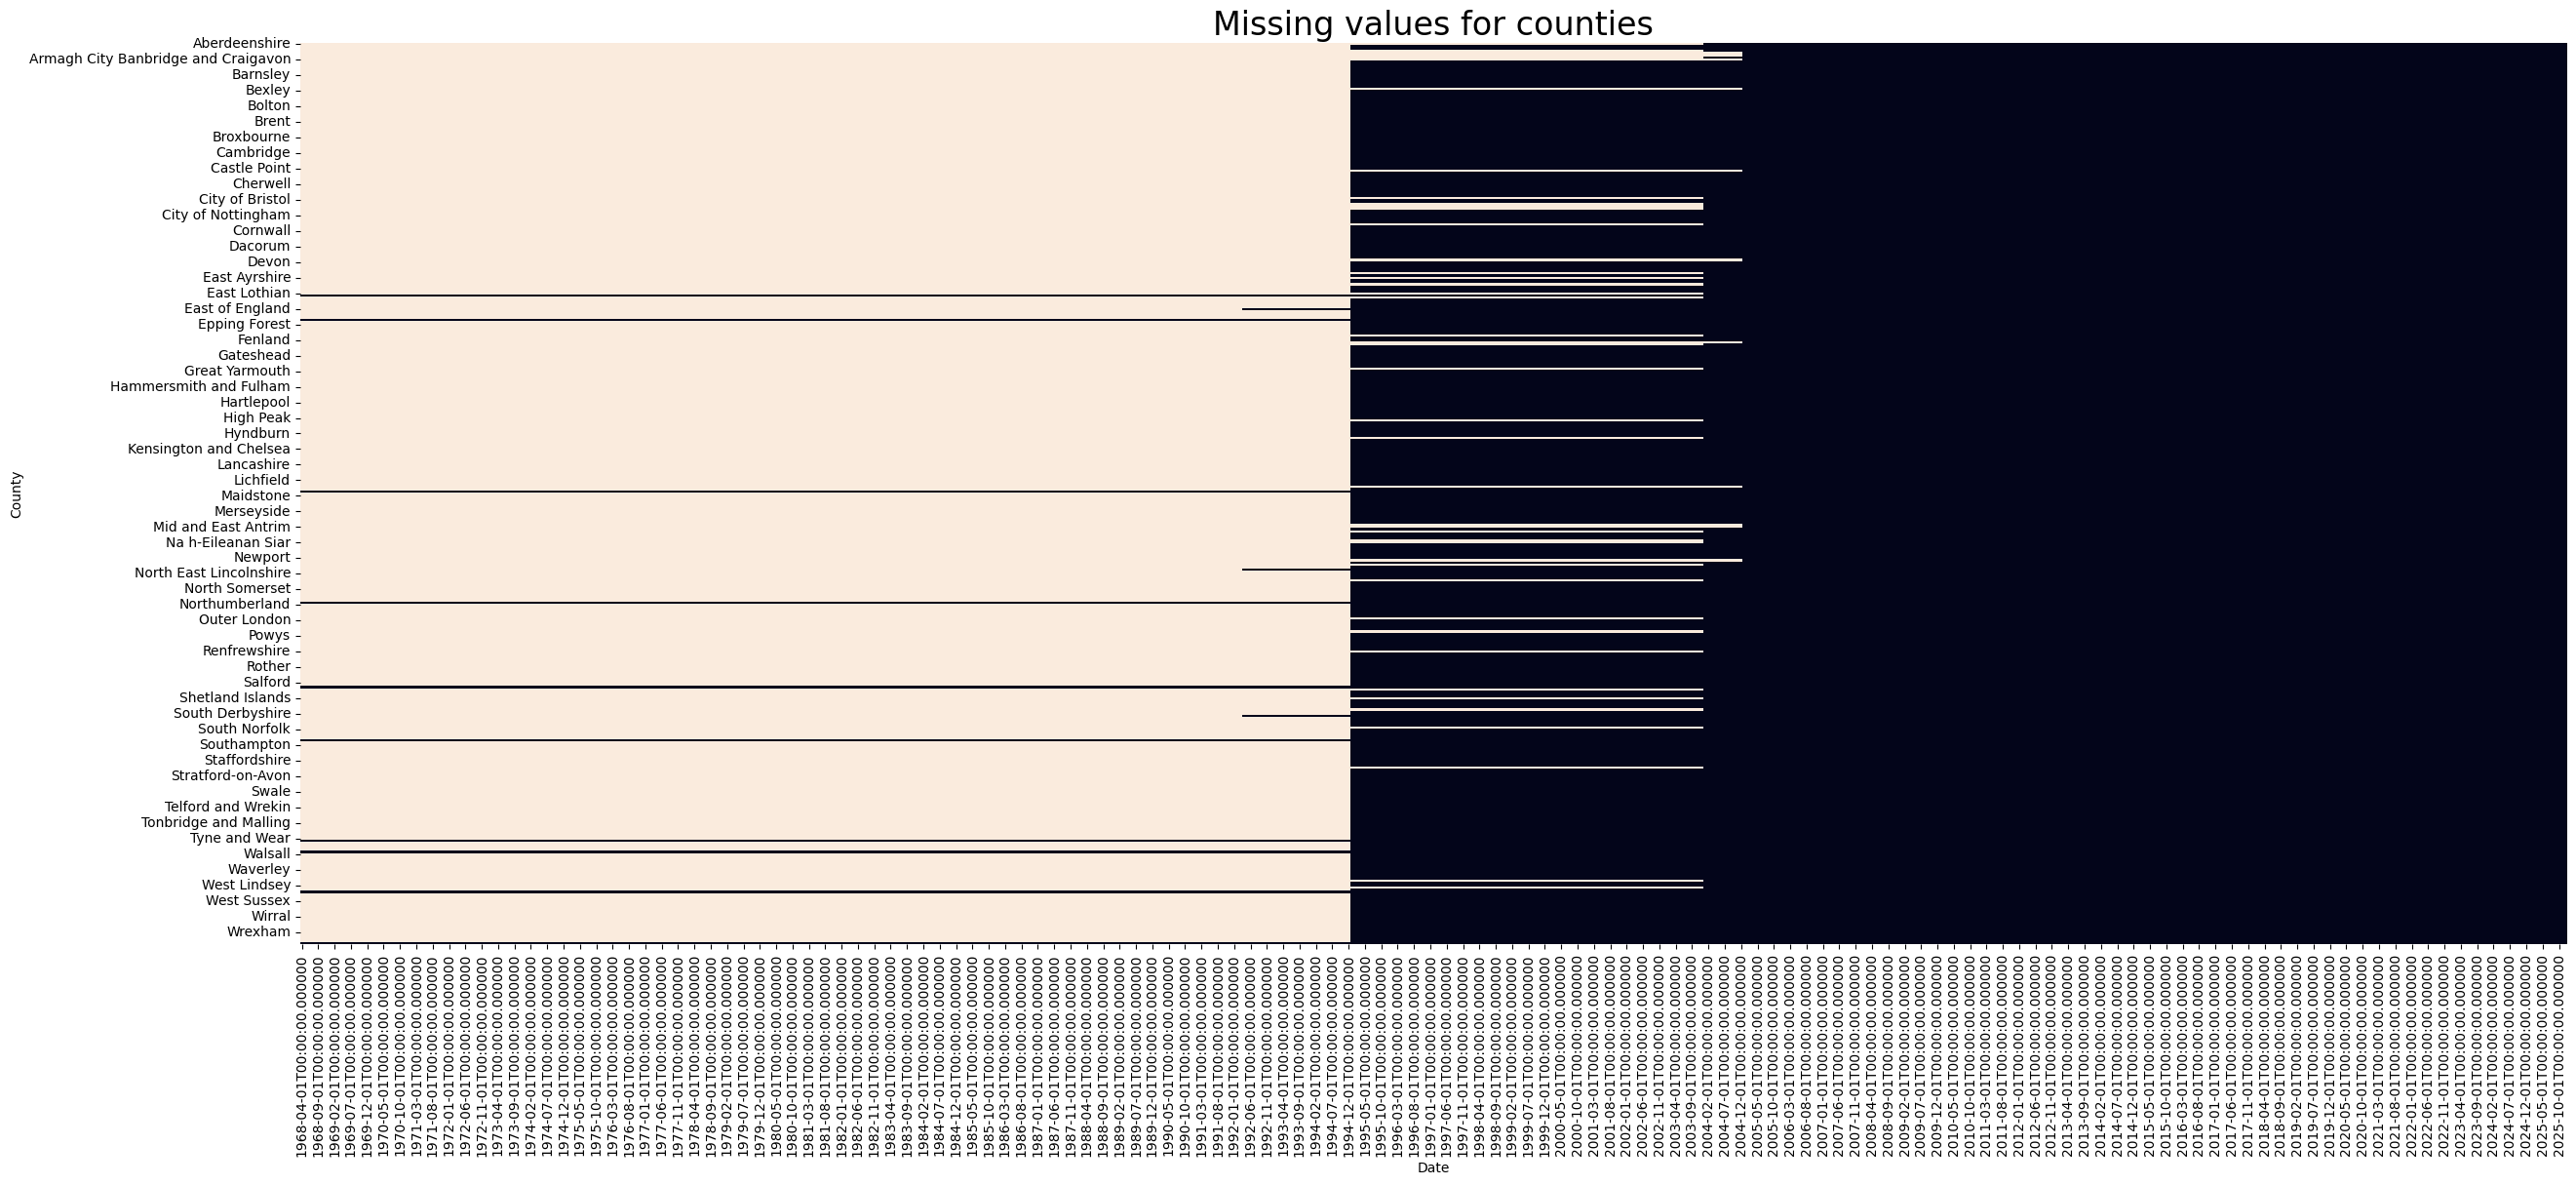

In [67]:
import seaborn as sns
plt.figure(figsize=(30,12))

sns.heatmap(df_county_date.isna(),cbar=False)
plt.title("Missing values for counties",fontsize=24)
plt.show()

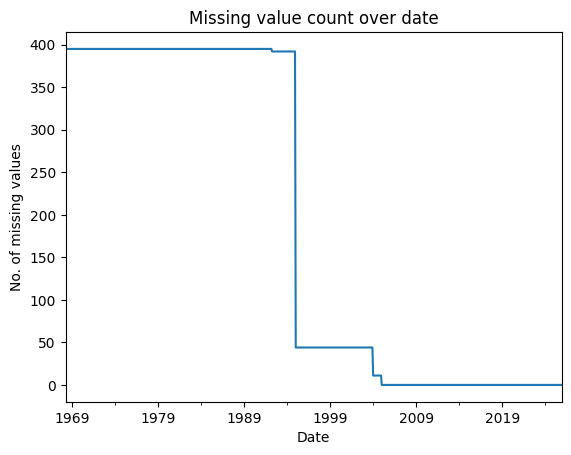

In [68]:
missing_values = df_county_date.isna().sum()
missing_values.plot()
plt.ylabel("No. of missing values")
plt.title("Missing value count over date")
plt.show()

In [69]:
print("Number of missing values 1970",missing_values.loc['1970'].mean())
print("Number of missing values 1990",missing_values.loc['1990'].mean())
print("Number of missing values 1994",missing_values.loc['1994'].mean())
print("Number of missing values 1995",missing_values.loc['1995'].mean())
print("Number of missing values 2000",missing_values.loc['2000'].mean())
print("Number of missing values 2003",missing_values.loc['2003'].mean())
print("Number of missing values 2004",missing_values.loc['2004'].mean())
print("Number of missing values 2005",missing_values.loc['2005'].mean())
print("Number of missing values 2010",missing_values.loc['2010'].mean())

Number of missing values 1970 395.0
Number of missing values 1990 395.0
Number of missing values 1994 392.0
Number of missing values 1995 44.0
Number of missing values 2000 44.0
Number of missing values 2003 44.0
Number of missing values 2004 11.0
Number of missing values 2005 0.0
Number of missing values 2010 0.0


__The dataset exhibits structural missingness prior to 2005, so I restrict analysis to a fully observed balanced panel from 2005 onward.__

In [71]:
data_s_05 = data_s_full[data_s_full['Date']>='2005']
data_s_05.sort_values(by=['County','Date'])
data_s_05

,County,Date,AreaCode,AveragePrice,Country,Region
12,Aberdeenshire,2005-01-01,S12000034,105489.0,S,Scotland
13,Aberdeenshire,2005-02-01,S12000034,101145.0,S,Scotland
14,Aberdeenshire,2005-03-01,S12000034,98196.0,S,Scotland
15,Aberdeenshire,2005-04-01,S12000034,99302.0,S,Scotland
16,Aberdeenshire,2005-05-01,S12000034,105412.0,S,Scotland
...,...,...,...,...,...,...
280231,Yorkshire and The Humber,2025-08-01,E12000003,206107.0,E,Yorkshire and the Humber
280232,Yorkshire and The Humber,2025-09-01,E12000003,206581.0,E,Yorkshire and the Humber
280233,Yorkshire and The Humber,2025-10-01,E12000003,206401.0,E,Yorkshire and the Humber
280234,Yorkshire and The Humber,2025-11-01,E12000003,209467.0,E,Yorkshire and the Humber


In [72]:
data_s_05.isna().sum()

County          0
Date            0
AreaCode        0
AveragePrice    0
Country         0
Region          0
dtype: int64

__Now we have a reduced dataset from 2005 onwards with no missing values.__  
Confirming the list of counties looks ok by visual inspection.

In [74]:
list_of_counties = data_s_05['County'].unique()
for i in list_of_counties:
    print(i,end=", ")    

Aberdeenshire, Adur, Amber Valley, Angus, Antrim and Newtownabbey, Ards and North Down, Argyll and Bute, Armagh City Banbridge and Craigavon, Arun, Ashfield, Ashford, Babergh, Barking and Dagenham, Barnet, Barnsley, Basildon, Basingstoke and Deane, Bassetlaw, Bath and North East Somerset, Bedford, Belfast, Bexley, Birmingham, Blaby, Blackburn with Darwen, Blackpool, Blaenau Gwent, Bolsover, Bolton, Boston, Bournemouth Christchurch and Poole, Bracknell Forest, Bradford, Braintree, Breckland, Brent, Brentwood, Bridgend, Brighton and Hove, Broadland, Bromley, Bromsgrove, Broxbourne, Broxtowe, Buckinghamshire, Burnley, Bury, Caerphilly, Calderdale, Cambridge, Cambridgeshire, Camden, Cannock Chase, Canterbury, Cardiff, Carmarthenshire, Castle Point, Causeway Coast and Glens, Central Bedfordshire, Ceredigion, Charnwood, Chelmsford, Cheltenham, Cherwell, Cheshire East, Cheshire West and Chester, Chesterfield, Chichester, Chorley, City of Aberdeen, City of Bristol, City of Derby, City of Dunde

__Let's output a new csv to work on now our dataset is ready for some further analysis.__

In [217]:
data_s_05.to_csv("../data/house_prices_full_cleaned.csv",index=False)

Let's have a look at that same pivot table now for our reduced date range

In [76]:
df_county_date = data_s_05.pivot_table(index='County',columns='Date',values='AveragePrice')
df_county_date

Date,2005-01-01,2005-02-01,2005-03-01,2005-04-01,2005-05-01,2005-06-01,2005-07-01,2005-08-01,2005-09-01,2005-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
County,,,,,,,,,,,,,,,,,,,,,
Aberdeenshire,105489.0,101145.0,98196.0,99302.0,105412.0,110561.0,112337.0,116017.0,117748.0,120861.0,...,193731.0,193159.0,196734.0,200115.0,201317.0,202951.0,201831.0,203136.0,201555.0,202362.0
Adur,183493.0,175825.0,178438.0,179535.0,183259.0,182181.0,179850.0,182674.0,184383.0,186795.0,...,372721.0,373551.0,376763.0,382977.0,378576.0,381370.0,382180.0,374865.0,372499.0,370708.0
Amber Valley,121782.0,122847.0,122490.0,126003.0,126294.0,129078.0,127970.0,126297.0,124372.0,123671.0,...,224300.0,223602.0,224311.0,224192.0,226413.0,230680.0,235285.0,238335.0,238246.0,234786.0
Angus,77436.0,77196.0,78040.0,81245.0,87424.0,89842.0,93388.0,94242.0,96509.0,97747.0,...,165304.0,166294.0,168141.0,170387.0,170632.0,167862.0,165145.0,167542.0,170210.0,174680.0
Antrim and Newtownabbey,107491.0,107491.0,107491.0,107298.0,107298.0,107298.0,116139.0,116139.0,116139.0,120436.0,...,189792.0,189463.0,189463.0,189463.0,195765.0,195765.0,195765.0,197918.0,197918.0,197918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wychavon,193661.0,192912.0,189999.0,187074.0,191725.0,194765.0,196859.0,195475.0,197418.0,197194.0,...,322202.0,317768.0,312704.0,314726.0,324802.0,330999.0,333782.0,331721.0,336679.0,333519.0
Wyre,137174.0,134850.0,132668.0,133198.0,135366.0,138126.0,141574.0,141390.0,140024.0,138041.0,...,191156.0,186363.0,183547.0,178896.0,183701.0,187061.0,188731.0,187052.0,187997.0,193044.0
Wyre Forest,138423.0,138375.0,139305.0,139231.0,142268.0,145143.0,150411.0,149447.0,148667.0,144913.0,...,232425.0,229063.0,229142.0,229485.0,236782.0,238175.0,236339.0,235202.0,233338.0,234081.0


<Axes: xlabel='Date'>

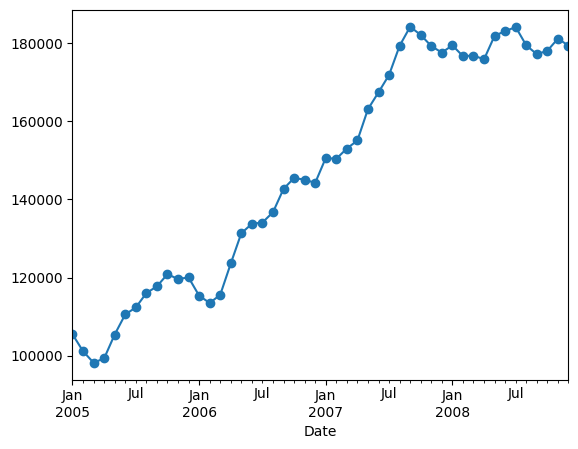

In [78]:
aberdeenshire_data = df_county_date.loc['Aberdeenshire']
aberdeenshire_data['2005':'2008'].plot(marker='o')

In [182]:
max_prices_per_county = df_county_date.T.max().sort_values(ascending=False)
max_prices_per_county

County
Kensington and Chelsea        1656986.0
City of Westminster           1224972.0
City of London                1021539.0
Camden                         948480.0
Hammersmith and Fulham         889834.0
                                ...    
East Ayrshire                  134249.0
City of Kingston upon Hull     132176.0
Burnley                        131476.0
West Dunbartonshire            131097.0
Inverclyde                     121039.0
Length: 405, dtype: float64

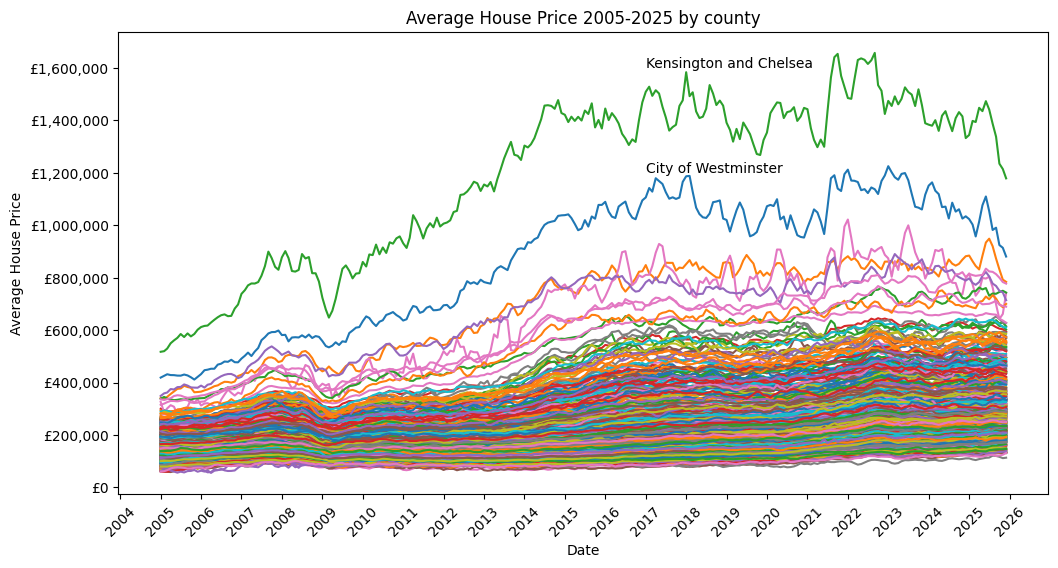

In [204]:
fig,ax = plt.subplots(figsize=(12,6))

ax.plot(df_county_date.T)

ax.set_ylabel('Average House Price')
ax.set_xlabel('Date')
ax.set_title('Average House Price 2005-2025 by county')
ax.ticklabel_format(style='plain',axis='y')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('£{x:,.0f}'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.tick_params(axis='x',rotation=45)
ax.annotate('Kensington and Chelsea',xy=(pd.Timestamp('2017'),1600000))
ax.annotate('City of Westminster',xy=(pd.Timestamp('2017'),1200000))

plt.show()

### 5. Comparing regions

Group by regions and produce a pivot table for average prices for each timestamp.

In [82]:
region_piv_tab = data_s_05.pivot_table(index='Region',columns='Date',values='AveragePrice',aggfunc='mean')
region_piv_tab.sort_index(axis=1)
region_piv_tab

Date,2005-01-01,2005-02-01,2005-03-01,2005-04-01,2005-05-01,2005-06-01,2005-07-01,2005-08-01,2005-09-01,2005-10-01,...,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01
Region,,,,,,,,,,,,,,,,,,,,,
East Midlands,135652.025000,134888.550000,134657.475000,136147.875000,137647.325000,138591.925000,139518.750000,140186.525000,140797.700000,141025.150000,...,243019.200000,240224.250000,239982.450000,238725.975000,242229.675000,244826.150000,246559.950000,247380.900000,247085.975000,247729.100000
East of England,183885.411765,182642.254902,182186.686275,181707.313725,183197.019608,184573.470588,186078.941176,186531.941176,187117.705882,187021.019608,...,356371.078431,353884.294118,354077.235294,354393.117647,358487.823529,361069.784314,361489.725490,362640.725490,362187.588235,361780.725490
London,262901.694444,260937.916667,262153.166667,264247.027778,265887.666667,267099.222222,268456.472222,269961.361111,270563.305556,269499.222222,...,595311.277778,599176.416667,602719.305556,608022.055556,606972.250000,603363.944444,599102.055556,586651.111111,583252.638889,580491.361111
North East England,106318.571429,106144.428571,105848.714286,107053.642857,109426.714286,111506.285714,113511.857143,115401.428571,115864.500000,115927.857143,...,160360.642857,158182.214286,158019.285714,157361.785714,160348.500000,162621.928571,163243.714286,163830.000000,165605.000000,165885.714286
North West England,114794.666667,114042.410256,114315.076923,115462.641026,117884.435897,119877.358974,121608.051282,122708.333333,123309.256410,123454.897436,...,208643.512821,205967.025641,205867.282051,204574.128205,208531.948718,211208.205128,212062.615385,212314.564103,212575.025641,213683.974359
Northern Ireland,106654.416667,106654.416667,106654.416667,111370.416667,111370.416667,111370.416667,118338.083333,118338.083333,118338.083333,122772.916667,...,185048.000000,186326.666667,186326.666667,186326.666667,194596.166667,194596.166667,194596.166667,197757.916667,197757.916667,197757.916667
Scotland,91146.151515,90641.303030,90538.909091,93083.454545,96024.393939,99854.484848,102080.636364,103862.393939,104552.818182,104431.575758,...,185201.333333,185761.909091,186976.212121,188140.696970,189543.181818,191582.515152,192532.121212,193455.515152,193265.757576,192545.000000
South East England,205182.816901,204076.126761,203639.211268,204443.042254,205204.352113,206191.352113,206985.253521,207749.507042,208519.859155,208343.971831,...,394221.690141,393235.492958,392234.887324,392727.929577,394259.000000,397504.985915,397738.746479,398121.239437,396416.971831,394392.830986
South West England,174834.551724,174706.275862,174172.758621,174000.344828,174541.862069,175572.206897,177320.655172,178265.862069,179181.206897,179194.620690,...,307944.896552,305494.896552,304830.517241,303813.862069,307452.586207,310474.413793,311840.827586,310846.068966,311101.482759,309878.448276


### Plot average price for regions over time

<Axes: xlabel='Date'>

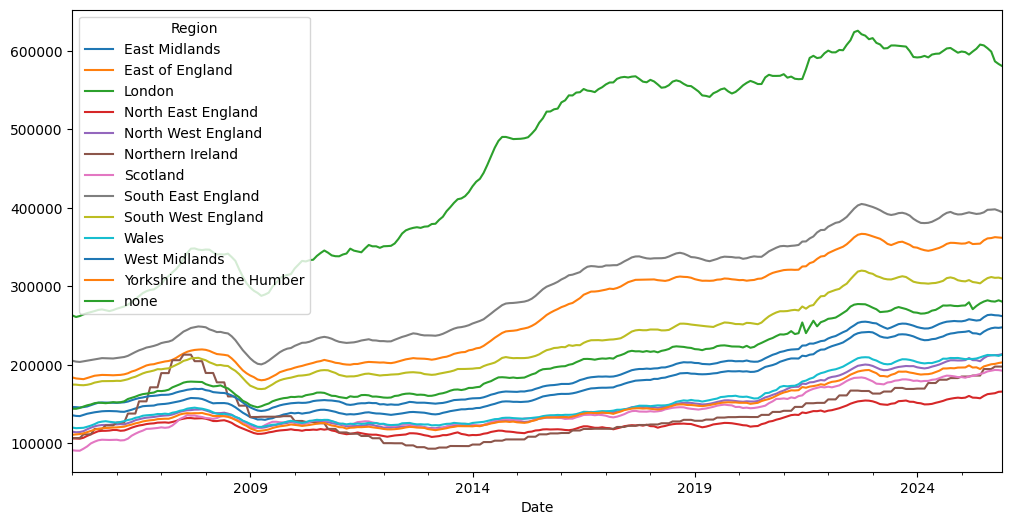

In [84]:
import matplotlib.pyplot as plt
region_piv_tab.T.plot(figsize=(12,6))


This may be a bit of a crude analysis however, consider factors such as the influence of varying house sizes for example.


In [86]:
'''
east_of_england = ['Babergh', 'Basildon', 'Bedford', 'Braintree', 'Breckland', 'Brentwood', 'Broadland',
                'Broxbourne', 'Cambridge', 'Castle Point', 'Central Bedfordshire', 'Chelmsford',
                'Colchester', 'Dacorum', 'East Cambridgeshire', 'East Hertfordshire', 'East Suffolk',
                'Epping Forest', 'Fenland', 'Great Yarmouth', 'Harlow', 'Hertsmere', 'Huntingdonshire',
                'Ipswich', 'Kings Lynn and West Norfolk', 'Luton', 'Maldon', 'Mid Suffolk', 'North Hertfordshire', 
                   'North Norfolk', 'Norwich', 'Peterborough', 'Rochford', 'South Cambridgeshire', 'South Norfolk', 
                   'Southend-on-Sea', 'St. Albans', 'Stevenage', 'Tendring',
                'Three Rivers', 'Thurrock', 'Uttlesford', 'Watford', 'Welwyn Hatfield', 'West Suffolk']

# check diff
east_diff = set(east_of_england) - set(region_names)
print(east_diff)

east_midlands = ['Amber Valley', 'Ashfield', 'Bassetlaw', 'Blaby', 'Bolsover', 'Boston', 'Broxtowe',
                'Charnwood', 'Chesterfield', 'Derby', 'Derbyshire Dales', 'East Lindsey', 'Erewash',
                'Gedling', 'Harborough', 'High Peak', 'Hinckley and Bosworth', 'Leicester', 'Lincoln',
                'Mansfield', 'Melton', 'Newark and Sherwood', 'North East Derbyshire', 'North Kesteven', 'North West Leicestershire', 
                 'North Northamptonshire', 'Nottingham','Oadby and Wigston', 'Rushcliffe', 'Rutland', 'South Derbyshire', 
                 'South Holland', 'South Kesteven', 'West Lindsey', 'West Northamptonshire']

# check diff
east_m_diff = set(east_midlands) - set(region_names)
print(east_m_diff)
'''

"\neast_of_england = ['Babergh', 'Basildon', 'Bedford', 'Braintree', 'Breckland', 'Brentwood', 'Broadland',\n                'Broxbourne', 'Cambridge', 'Castle Point', 'Central Bedfordshire', 'Chelmsford',\n                'Colchester', 'Dacorum', 'East Cambridgeshire', 'East Hertfordshire', 'East Suffolk',\n                'Epping Forest', 'Fenland', 'Great Yarmouth', 'Harlow', 'Hertsmere', 'Huntingdonshire',\n                'Ipswich', 'Kings Lynn and West Norfolk', 'Luton', 'Maldon', 'Mid Suffolk', 'North Hertfordshire', \n                   'North Norfolk', 'Norwich', 'Peterborough', 'Rochford', 'South Cambridgeshire', 'South Norfolk', \n                   'Southend-on-Sea', 'St. Albans', 'Stevenage', 'Tendring',\n                'Three Rivers', 'Thurrock', 'Uttlesford', 'Watford', 'Welwyn Hatfield', 'West Suffolk']\n\n# check diff\neast_diff = set(east_of_england) - set(region_names)\nprint(east_diff)\n\neast_midlands = ['Amber Valley', 'Ashfield', 'Bassetlaw', 'Blaby', 'Bolsover'

### Use the government uk counties and unitary boundaries map
https://www.data.gov.uk/dataset/85228aec-fe0e-49bf-9455-df000d61e731/counties-and-unitary-authorities-may-2023-boundaries-uk-bgc

In [88]:
import geopandas as gpd
geodata = "../data/uk-counties.geojson"
map_df = gpd.read_file(geodata)
print(map_df.columns)

Index(['FID', 'CTYUA23CD', 'CTYUA23NM', 'CTYUA23NMW', 'BNG_E', 'BNG_N', 'LONG',
       'LAT', 'GlobalID', 'geometry'],
      dtype='str')
